[Previous: Module 7: Grover's Search](07_Grovers_Search.ipynb)  |  [Course Index](00_Start_Here.ipynb)

# Module 8: Noise, Real Hardware & Error Correction

**Learning objectives.** After this module you can:

* name the main error sources in a real quantum computer and model them in the Aer simulator;
* show that errors compound with circuit depth, and why that limits today's machines;
* transpile a circuit to a device's gate set and connectivity, and see why the *same* state can cost very different depths;
* run the three-qubit repetition code and demonstrate that encoding reduces the logical error rate.

**Prerequisites.** All of modules 1-7; this module reuses Bell and GHZ states, and Grover.

## 1. What goes wrong in a real device

Every simulation so far was *ideal*. Real qubits are physical systems (superconducting circuits, trapped ions, photons) that interact with their surroundings
whether you want them to or not.

| Error source | What happens | Typical size (2020s superconducting hardware) |
|---|---|---|
| **Decoherence** ($T_1$, $T_2$) | the state relaxes to $\lvert 0\rangle$ or loses its phase over time | $T_1, T_2 \sim 100\,\mu s$; a gate takes $\sim 0.1\,\mu s$ |
| **Gate error** | each gate is a slightly wrong rotation | $10^{-4}$-$10^{-3}$ for 1-qubit gates, $10^{-3}$-$10^{-2}$ for 2-qubit gates |
| **Readout error** | a $0$ is reported as $1$ or vice versa | $\sim 1$-$3\,\%$ |
| **Crosstalk** | operating one qubit disturbs its neighbours | varies |
| **Limited connectivity** | two-qubit gates only between physically wired qubits | forces extra SWAP gates |

The two-qubit gate error dominates, and errors *accumulate*: a circuit with 100 CNOTs at 1 % error each is nearly hopeless without correction.

## 2. Building a noise model

Aer lets you attach errors to gates. A **depolarizing** error replaces the state with a random one with probability $p$; it is the standard stand-in for gate error.
A **readout error** flips measurement results with given probabilities. We assign 0.1 % to single-qubit gates, 2 % to CNOT and a 2-3 % readout flip.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, pauli_error, ReadoutError

ideal = AerSimulator()

def make_noise_model(p1=0.001, p2=0.02, readout=(0.02, 0.03)):
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ['h', 'x', 'y', 'z', 's', 'sdg', 't', 'rz', 'sx', 'ry', 'u'])
    nm.add_all_qubit_quantum_error(depolarizing_error(p2, 2), ['cx', 'cz'])
    p0to1, p1to0 = readout
    nm.add_all_qubit_readout_error(ReadoutError([[1 - p0to1, p0to1], [p1to0, 1 - p1to0]]))
    return nm

noise_model = make_noise_model()
noisy = AerSimulator(noise_model=noise_model)
print(noise_model)

NoiseModel:
  Basis gates: ['cx', 'cz', 'h', 'id', 'ry', 'rz', 's', 'sdg', 'sx', 't', 'u', 'x', 'y', 'z']
  Instructions with noise: ['z', 'cz', 'y', 'rz', 's', 'measure', 'sx', 'x', 'cx', 't', 'ry', 'u', 'sdg', 'h']
  All-qubits errors: ['h', 'x', 'y', 'z', 's', 'sdg', 't', 'rz', 'sx', 'ry', 'u', 'cx', 'cz', 'measure']


ideal: {'00': 2054, '11': 1946}
noisy: {'01': 116, '10': 112, '11': 1856, '00': 1916}


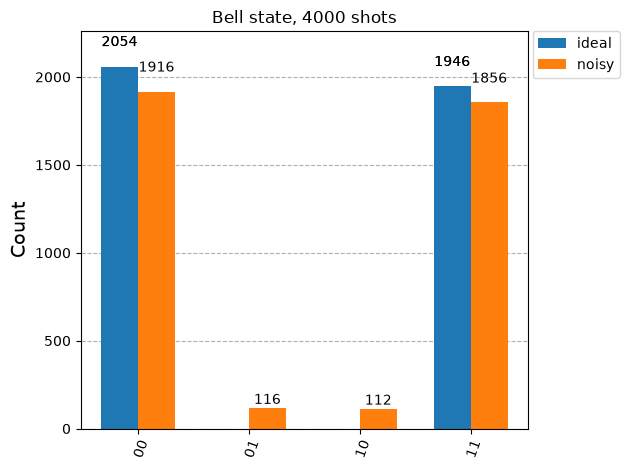

In [2]:
bell = QuantumCircuit(2, 2)
bell.h(0); bell.cx(0, 1)
bell.measure([0, 1], [0, 1])

counts_ideal = ideal.run(transpile(bell, ideal), shots=4000).result().get_counts()
counts_noisy = noisy.run(transpile(bell, noisy), shots=4000).result().get_counts()

print("ideal:", counts_ideal)
print("noisy:", counts_noisy)
plot_histogram([counts_ideal, counts_noisy], legend=['ideal', 'noisy'], title="Bell state, 4000 shots")

> **What to notice.** The impossible outcomes `01` and `10` now appear a few percent of the time. Most of that is readout error;
> the rest is the CNOT. With a single short circuit the answer is still obvious, but it is no longer *certain*.

## 3. Errors compound with depth

Apply a CNOT twice and you have the identity: the ideal output is `00` forever, however many pairs you add.
With noise, every extra gate is another chance to go wrong, and the success probability decays roughly as $(1-p)^{\text{gates}}$.

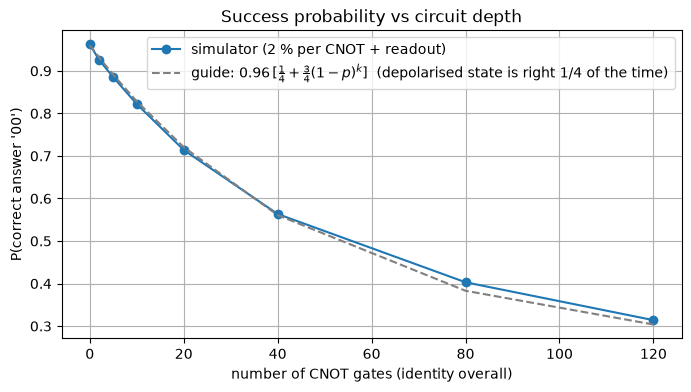

In [3]:
depths = [0, 2, 5, 10, 20, 40, 80, 120]
success = []
for k in depths:
    qc = QuantumCircuit(2, 2)
    for _ in range(k):
        qc.cx(0, 1)
        qc.barrier()             # barriers stop the transpiler from cancelling the CNOT pairs
    qc.measure([0, 1], [0, 1])
    counts = noisy.run(transpile(qc, noisy, optimization_level=0), shots=2000).result().get_counts()
    success.append(counts.get('00', 0) / 2000)

plt.figure(figsize=(8, 4))
plt.plot(depths, success, 'o-', label='simulator (2 % per CNOT + readout)')
p2 = 0.02
k = np.array(depths)
plt.plot(k, 0.96 * (0.25 + 0.75 * (1 - p2)**k), '--', color='gray',
         label=r'guide: $0.96\,[\frac{1}{4} + \frac{3}{4}(1-p)^{k}]$  (depolarised state is right 1/4 of the time)')
plt.xlabel('number of CNOT gates (identity overall)'); plt.ylabel("P(correct answer '00')")
plt.title('Success probability vs circuit depth'); plt.legend(); plt.grid(True); plt.show()

> **What to notice.** After about a hundred two-qubit gates the "certain" answer is right only about a third of the time.
> This is why current algorithms are judged by *depth* and *two-qubit gate count*, and why Module 7's Grover circuit, with its many multi-controlled gates, is hard to run on real devices for more than a few qubits.

## 4. Transpiling to a real device

A real backend supports a small **basis gate set** (typically `rz`, `sx`, `x`, `cx`) and a **coupling map** listing which qubit pairs can share a CNOT.
`transpile` rewrites your circuit to obey both: every gate is decomposed into the basis, and non-adjacent CNOTs are routed with SWAP gates
(each SWAP is three CNOTs).

Qiskit ships `GenericBackendV2`, a stand-in for a real device with realistic gate times and error rates. We give it five qubits wired in a line.

basis gates : ['cx', 'id', 'rz', 'sx', 'x', 'reset', 'delay', 'measure']
coupling map: [(0, 1), (1, 2), (2, 3), (3, 4)]


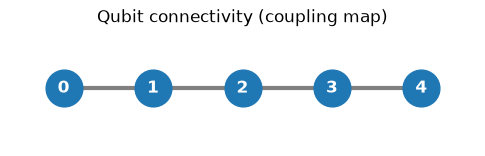

In [4]:
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import CouplingMap

backend = GenericBackendV2(num_qubits=5, coupling_map=CouplingMap.from_line(5), seed=42)
print("basis gates :", backend.operation_names)
print("coupling map:", sorted(set(tuple(sorted(e)) for e in backend.coupling_map.get_edges())))

def draw_coupling_map(backend):
    n = backend.num_qubits
    edges = set(tuple(sorted(e)) for e in backend.coupling_map.get_edges())
    xs, ys = np.arange(n), np.zeros(n)
    fig, ax = plt.subplots(figsize=(6, 1.5))
    for a, b in edges:
        ax.plot([xs[a], xs[b]], [ys[a], ys[b]], color='gray', lw=3, zorder=1)
    ax.scatter(xs, ys, s=700, color='tab:blue', zorder=2)
    for i in range(n):
        ax.text(xs[i], ys[i], str(i), ha='center', va='center', color='white', fontsize=12, fontweight='bold')
    ax.set_xlim(-0.6, n - 0.4); ax.axis('off'); ax.set_title('Qubit connectivity (coupling map)')
    plt.show()

draw_coupling_map(backend)

Both give the same ideal state: True

star   after transpile: depth = 21, CNOTs = 10, all ops = {'cx': 10, 'rz': 9, 'sx': 5, 'measure': 5, 'x': 1}

chain  after transpile: depth = 13, CNOTs = 4, all ops = {'rz': 8, 'sx': 5, 'measure': 5, 'cx': 4}

The star circuit as the device actually runs it (SWAPs became extra CNOTs):


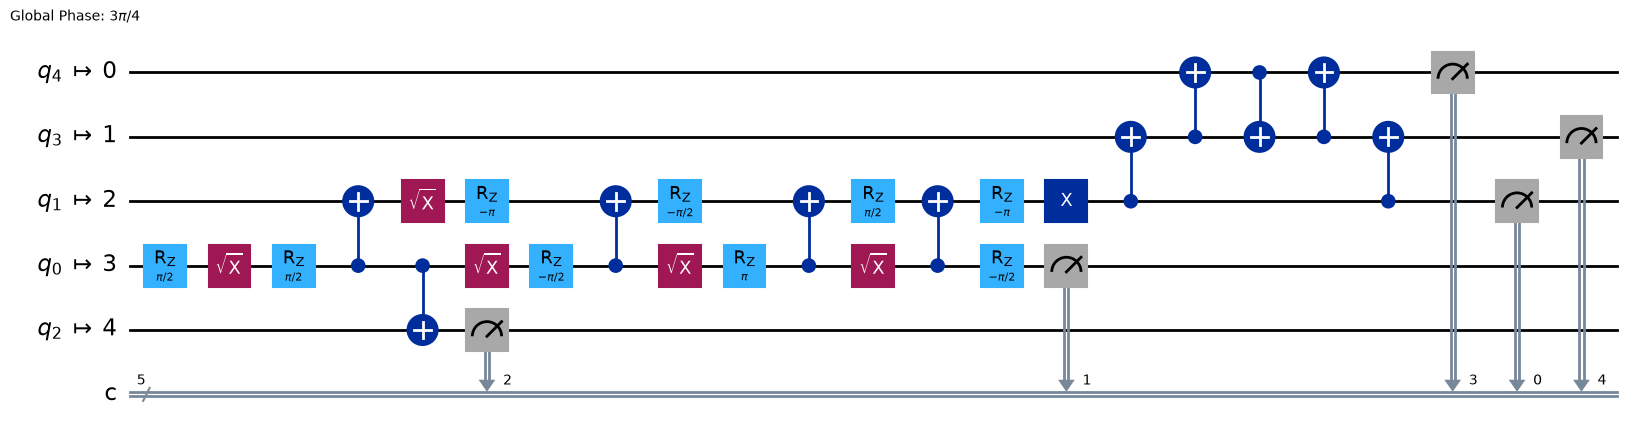

In [5]:
# Two circuits for the SAME 5-qubit GHZ state.
star = QuantumCircuit(5, 5)                       # naive: qubit 0 controls everything
star.h(0)
for t in range(1, 5): star.cx(0, t)
star.measure(range(5), range(5))

chain = QuantumCircuit(5, 5)                      # hardware-aware: only neighbouring pairs
chain.h(0)
for t in range(1, 5): chain.cx(t - 1, t)
chain.measure(range(5), range(5))

print("Both give the same ideal state:",
      Statevector(star.remove_final_measurements(inplace=False)).equiv(Statevector(chain.remove_final_measurements(inplace=False))))

for name, qc in [("star", star), ("chain", chain)]:
    tqc = transpile(qc, backend, seed_transpiler=1)
    ops = tqc.count_ops()
    print(f"\n{name:<6} after transpile: depth = {tqc.depth()}, CNOTs = {ops.get('cx', 0)}, all ops = {dict(ops)}")

print("\nThe star circuit as the device actually runs it (SWAPs became extra CNOTs):")
transpile(star, backend, seed_transpiler=1).draw('mpl', fold=-1)

star   P(00000 or 11111) = 0.962


chain  P(00000 or 11111) = 0.979


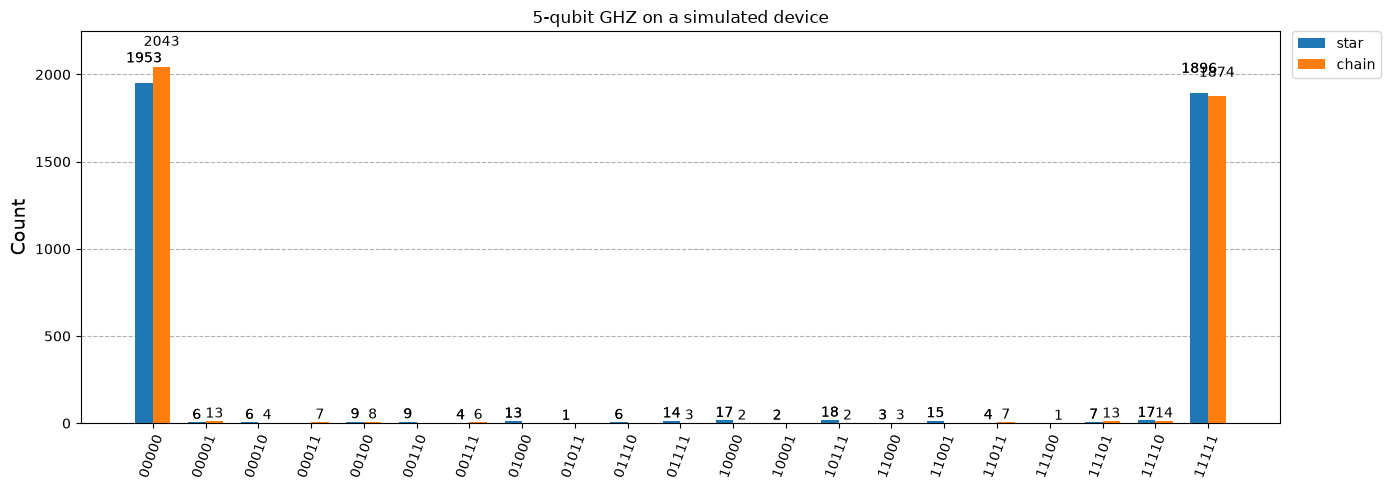

In [6]:
# Run both on a noisy simulator built from the backend's own error rates.
device_sim = AerSimulator.from_backend(backend)

results = {}
for name, qc in [("star", star), ("chain", chain)]:
    tqc = transpile(qc, backend, seed_transpiler=1)
    counts = device_sim.run(tqc, shots=4000).result().get_counts()
    fidelity_proxy = (counts.get('00000', 0) + counts.get('11111', 0)) / 4000
    results[name] = counts
    print(f"{name:<6} P(00000 or 11111) = {fidelity_proxy:.3f}")

plot_histogram(list(results.values()), legend=list(results.keys()), title="5-qubit GHZ on a simulated device", figsize=(14, 5))

> **What to notice.** Same state, same qubits, but the star layout needs SWAPs, so it has more CNOTs and more depth, and it comes out measurably worse.
> On this mildly noisy model the gap is a couple of percent; on a real device, or with more qubits, it grows quickly. *How* you write a circuit matters as much as *what* it computes.

## 5. Error correction: the three-qubit repetition code

If single bits were this unreliable, classical engineers would store each bit three times and take a majority vote. The quantum version is the
**bit-flip repetition code**:

1. **Encode** $\alpha|0\rangle + \beta|1\rangle \to \alpha|000\rangle + \beta|111\rangle$ with two CNOTs. (This is *not* cloning: it is a GHZ-like entangled state, not three copies.)
2. **Noise** flips each qubit independently with probability $p$.
3. **Decode** with the same two CNOTs plus a Toffoli, which flips qubit 0 back if *both* other qubits disagree with it, i.e. a majority vote in reversible logic.

A single flip on any qubit is corrected. Only two or more flips cause a logical error, so the logical error rate is
$$p_L = 3p^2(1-p) + p^3 = 3p^2 - 2p^3,$$
which is *smaller* than $p$ whenever $p < \tfrac12$. Below we measure exactly this, with the noise injected through identity gates.

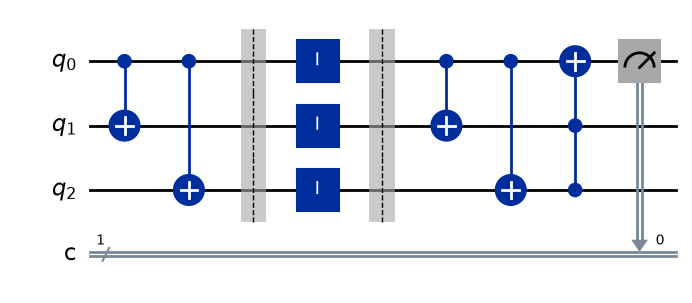

physical flip rate 10 %  ->  logical error rate 2.7%   (theory 3p²-2p³ = 2.8%)


In [7]:
def repetition_code_experiment(p, shots=4000, encode=True):
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(pauli_error([('X', p), ('I', 1 - p)]), ['id'])   # bit flip with probability p
    sim = AerSimulator(noise_model=nm)

    qc = QuantumCircuit(3, 1)
    if encode:
        qc.cx(0, 1); qc.cx(0, 2)          # encode |ψ> -> α|000> + β|111>
    qc.barrier()
    qc.id([0, 1, 2])                      # the noisy "memory" step
    qc.barrier()
    if encode:
        qc.cx(0, 1); qc.cx(0, 2)          # decode
        qc.ccx(2, 1, 0)                   # majority vote: fix qubit 0 if both others flipped
    qc.measure(0, 0)
    counts = sim.run(qc, shots=shots).result().get_counts()
    return counts.get('1', 0) / shots, qc

logical_error, circuit = repetition_code_experiment(0.1)
display(circuit.draw('mpl'))
print(f"physical flip rate 10 %  ->  logical error rate {logical_error:.1%}   (theory 3p²-2p³ = {3*0.01 - 2*0.001:.1%})")

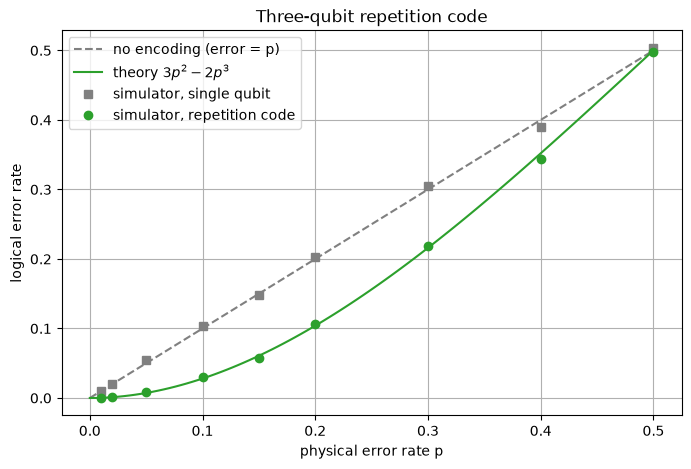

In [8]:
ps = [0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
encoded   = [repetition_code_experiment(p)[0] for p in ps]
unencoded = [repetition_code_experiment(p, encode=False)[0] for p in ps]

p_line = np.linspace(0, 0.5, 100)
plt.figure(figsize=(8, 5))
plt.plot(p_line, p_line, '--', color='gray', label='no encoding (error = p)')
plt.plot(p_line, 3*p_line**2 - 2*p_line**3, '-', color='tab:green', label=r'theory $3p^2 - 2p^3$')
plt.plot(ps, unencoded, 's', color='gray', label='simulator, single qubit')
plt.plot(ps, encoded, 'o', color='tab:green', label='simulator, repetition code')
plt.xlabel('physical error rate p'); plt.ylabel('logical error rate')
plt.title('Three-qubit repetition code'); plt.legend(); plt.grid(True); plt.show()

> **What to notice.** At $p = 0.1$ the encoded qubit fails about 3 % of the time instead of 10 %. At $p = 0.01$ it is 0.03 % instead of 1 %.
> Below the crossover at $p = 0.5$, encoding always helps, and the benefit grows fast as the hardware improves. This is the **threshold** idea that makes
> fault-tolerant quantum computing possible.
>
> **The catch.** This code only corrects bit flips (X errors). A phase flip (Z) passes straight through it. Real codes such as the **surface code** protect against both,
> at the cost of many more physical qubits per logical qubit. That overhead is the central engineering problem of the field today.

## 6. Where to go next

* **Run on real hardware.** Install `qiskit-ibm-runtime`, create a free IBM Quantum account, and submit the Bell circuit from Module 3. Compare the histogram with section 2.
* **Error mitigation.** Techniques such as readout calibration and zero-noise extrapolation squeeze better answers out of noisy runs without full error correction.
* **More algorithms.** Quantum phase estimation and Shor's algorithm (the exponential speed-up for factoring), variational algorithms (VQE, QAOA) for chemistry and optimisation.
* **Reading.** *Quantum Computation and Quantum Information* (Nielsen & Chuang) is the reference; the Qiskit textbook and John Preskill's lecture notes are free online.

## Try it yourself

**Exercise 1.** Raise the CNOT error in `make_noise_model` to 5 %. How deep can a circuit be before P(correct) drops below 50 %?

**Exercise 2.** Run the Module 7 Grover circuit ($n = 3$, 2 iterations) on `device_sim` after transpiling to `backend`. Is the marked item still the most likely outcome?

**Exercise 3.** Replace the bit-flip noise in the repetition code with a *phase* flip: `pauli_error([('Z', p), ('I', 1-p)])`, and prepare $|+\rangle$ on qubit 0 before encoding
(then apply H before measuring). Show the code no longer helps.

**Exercise 4 (challenge).** Fix Exercise 3 with the phase-flip code: sandwich the noisy step between layers of H gates on all three qubits.

<details><summary>Solutions (2 and 4 sketch)</summary>

```python
# Exercise 2 (requires the grover() function from Module 7 to be defined in this kernel)
# tqc = transpile(grover(3, '101', 2), backend, seed_transpiler=1)
# print(tqc.depth(), tqc.count_ops().get('cx'))
# plot_histogram(device_sim.run(tqc, shots=4000).result().get_counts())
# With ~50+ CNOTs after transpilation the peak is much lower, but usually still visible.

# Exercise 4: H maps Z errors to X errors, which the code can fix.
# encode; qc.h([0,1,2]); qc.id([0,1,2]) with Z noise; qc.h([0,1,2]); decode.
```

</details>

## Key takeaways

* Real devices suffer gate errors (worst for two-qubit gates), decoherence and readout errors. Aer's `NoiseModel` reproduces all three.
* Errors compound with depth; two-qubit gate count is the currency of near-term quantum computing.
* `transpile` adapts a circuit to a device's basis gates and connectivity; hardware-aware circuits can be several times shallower.
* The repetition code turns physical error $p$ into logical error $3p^2$: below threshold, redundancy wins. Full error correction extends this to all error types.

You have reached the end of the course. Go back to the [Course Index](00_Start_Here.ipynb), or start modifying the notebooks: the best way to learn quantum computing is to break these circuits and understand why.

[Previous: Module 7: Grover's Search](07_Grovers_Search.ipynb)  |  [Course Index](00_Start_Here.ipynb)